Train acc: 0.9868131868131869
Test acc: 0.9824561403508771


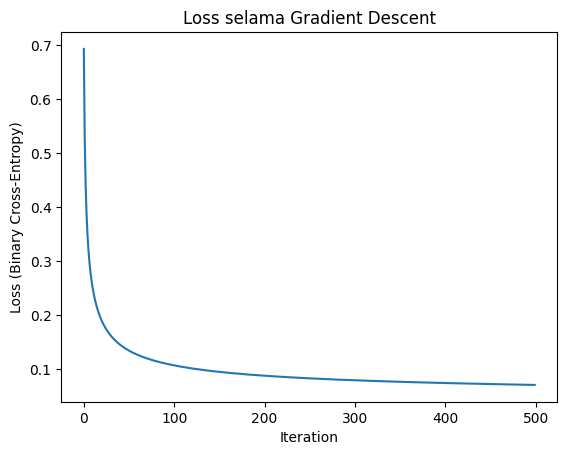

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# ---------- Core functions ----------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def calculate_gradient(theta, X, y):
    m = y.size  # number of instances
    return (X.T @ (sigmoid(X @ theta) - y)) / m


def compute_loss(theta, X, y, eps=1e-15):
    m = y.size
    p = sigmoid(X @ theta)
    p = np.clip(p, eps, 1 - eps)  # avoid log(0)
    return -(1 / m) * np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


def gradient_descent(X, y, alpha=0.1, num_iter=500, tol=1e-7, return_history=False):
    # add bias term
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    theta = np.zeros(X_b.shape[1])

    losses = []
    for i in range(num_iter):
        # track loss (before update)
        losses.append(compute_loss(theta, X_b, y))

        grad = calculate_gradient(theta, X_b, y)
        theta -= alpha * grad

        if np.linalg.norm(grad) < tol:
            break

    if return_history:
        return theta, losses
    return theta


def predict_proba(X, theta):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return sigmoid(X_b @ theta)


def predict(X, theta, threshold=0.5):
    return (predict_proba(X, theta) >= threshold).astype(int)


# ---------- Load data ----------
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------- Scale features ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------- Train + track loss ----------
theta_hat, losses = gradient_descent(
    X_train_scaled, y_train, alpha=0.1, num_iter=500, tol=1e-7, return_history=True
)

# ---------- Predict ----------
y_pred_train = predict(X_train_scaled, theta_hat)
y_pred_test = predict(X_test_scaled, theta_hat)

# ---------- Evaluate ----------
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("Train acc:", train_acc)
print("Test acc:", test_acc)

# ---------- Plot loss ----------
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss (Binary Cross-Entropy)")
plt.title("Loss selama Gradient Descent")
plt.show()